# Import Library

In [1]:
!pip install tensorflow

In [2]:
import math
import random
import pickle
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import time
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    label_ranking_average_precision_score,
    label_ranking_loss,
    coverage_error)
from sklearn.utils import shuffle
from scipy.signal import resample
from sklearn.preprocessing import OneHotEncoder
from keras.models import Model
from keras.layers import (
    Input,
    Dense,
    Conv1D,
    MaxPooling1D,
    Softmax,
    Add,
    Flatten,
    Activation,
    Dropout,
    GlobalAveragePooling1D,
    LayerNormalization,
    MultiHeadAttention,
    Embedding,
    Layer,
    Bidirectional,
    LSTM)
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(42)

# Exploratory Data Analysis - EDA

## Membaca Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Path to dataset files:", path)

df1 = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
df2 = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
df = pd.concat([df1, df2])

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat


In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualisasi Sinyal

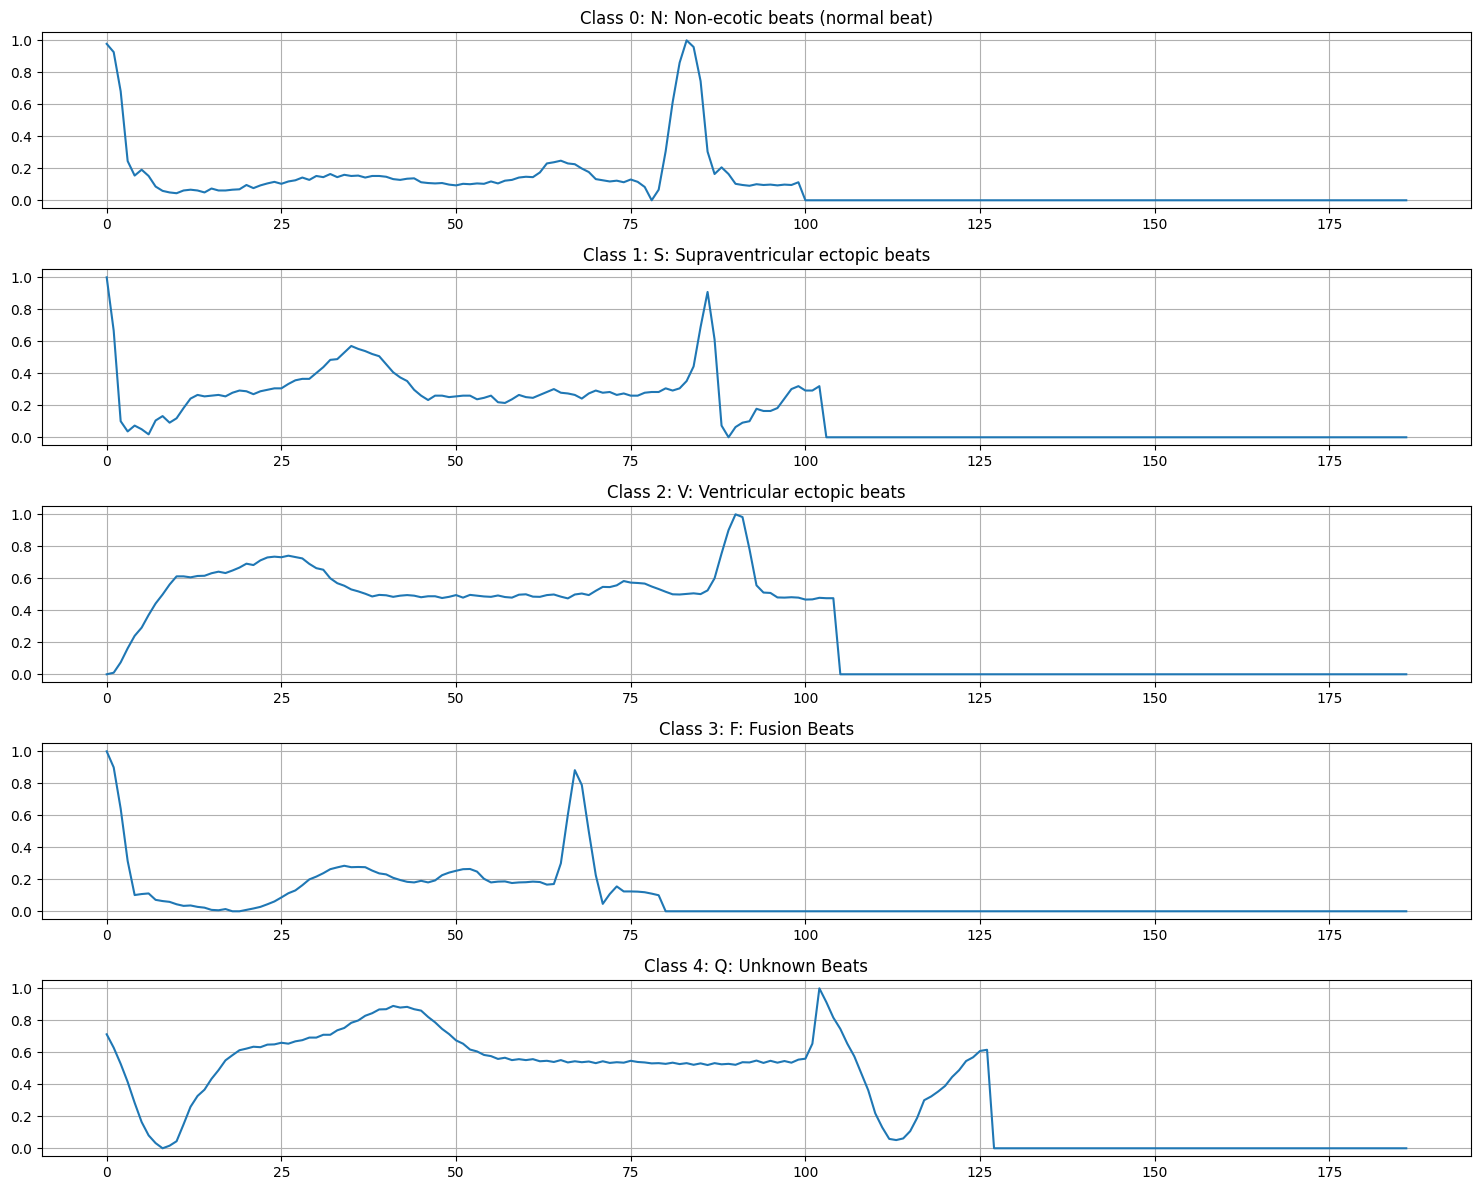

In [5]:
classes = [0, 1, 2, 3, 4]
labels = [
    'N: Non-ecotic beats (normal beat)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(15, 12))

for i, cls in enumerate(classes):
    # Ambil sampel pertama untuk setiap kelas
    sample = df[df[187] == cls].iloc[0, :187]

    plt.subplot(5, 1, i + 1)
    plt.plot(sample)
    plt.title(f"Class {cls}: {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Analisis Distribusi Kelas

Jumlah sampel per kelas:
187
0.0    90589
1.0     2779
2.0     7236
3.0      803
4.0     8039
Name: count, dtype: int64


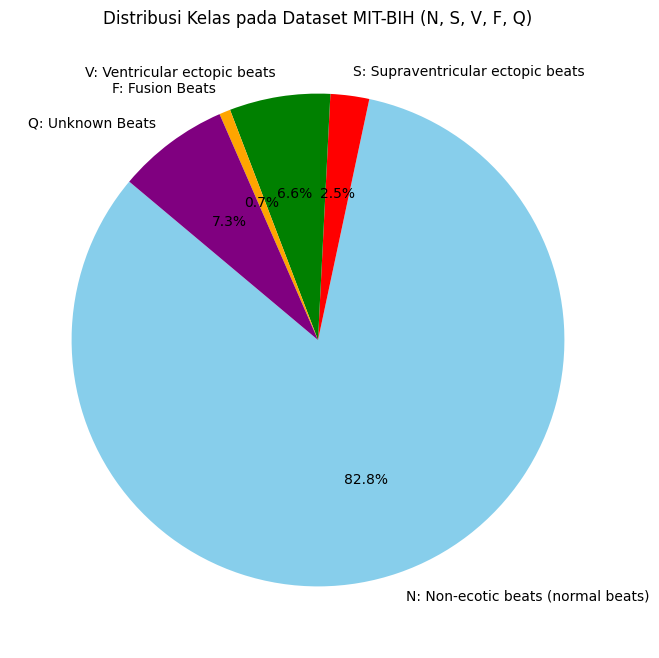

In [6]:
count_classes = df[187].value_counts().sort_index()
print("Jumlah sampel per kelas:")
print(count_classes)

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(10, 8))
plt.pie(count_classes, labels=labels_detailed, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'red', 'green', 'orange', 'purple'])
plt.title("Distribusi Kelas pada Dataset MIT-BIH (N, S, V, F, Q)")
plt.show()

# Data Preprocessing

## Pemisahan Fitur dan Target

In [7]:
X = df.iloc[:, :187].values
y = df.iloc[:, 187].values

print("Ukuran Fitur (X):", X.shape)
print("Ukuran Target (y):", y.shape)

Ukuran Fitur (X): (109446, 187)
Ukuran Target (y): (109446,)


## Penanganan Data Tidak Seimbang

In [8]:
def resample_dataset(df):
    # Pisahkan setiap kelas
    df_0 = df[df[187] == 0]
    df_1 = df[df[187] == 1]
    df_2 = df[df[187] == 2]
    df_3 = df[df[187] == 3]
    df_4 = df[df[187] == 4]

    # Target jumlah sampel per kelas
    target_samples = 20000

    # Resampling untuk setiap kelas
    df_0_resampled = df_0.sample(n=target_samples, random_state=42) # Undersampling
    df_1_resampled = df_1.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_2_resampled = df_2.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_3_resampled = df_3.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_4_resampled = df_4.sample(n=target_samples, replace=True, random_state=42) # Oversampling

    # Gabungkan kembali
    df_resampled = pd.concat([df_0_resampled, df_1_resampled, df_2_resampled, df_3_resampled, df_4_resampled])
    return df_resampled

# Terapkan resampling
df_balanced = resample_dataset(df)

# Update X dan y dengan data yang sudah seimbang
X_balanced = df_balanced.iloc[:, :187].values
y_balanced = df_balanced.iloc[:, 187].values

print("Distribusi kelas setelah resampling:")
print(df_balanced[187].value_counts().sort_index())
print("\nUkuran X_balanced:", X_balanced.shape)

Distribusi kelas setelah resampling:
187
0.0    20000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64

Ukuran X_balanced: (100000, 187)


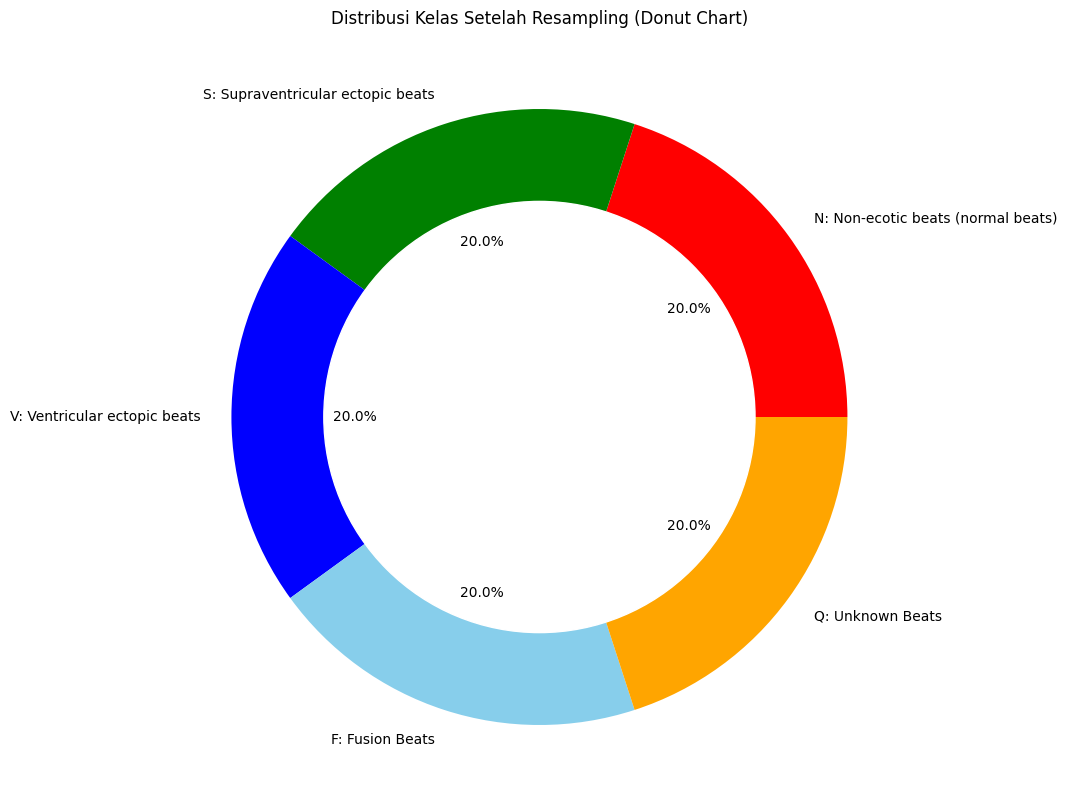

In [9]:
equilibre = df_balanced[187].value_counts()

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(20,10))
my_circle = plt.Circle((0,0), 0.7, color='white')
plt.pie(equilibre, labels=labels_detailed, colors=['red','green','blue','skyblue','orange'], autopct='%1.1f%%')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Distribusi Kelas Setelah Resampling (Donut Chart)")
plt.show()

## Reshaping Data

In [10]:
# Reshaping data fitur dari 2D (100000, 187) menjadi 3D (100000, 187, 1)
X_3d = X_balanced.reshape(X_balanced.shape[0], X_balanced.shape[1], 1)

print("Ukuran X_balanced awal:", X_balanced.shape)
print("Ukuran X setelah Reshape (X_3d):", X_3d.shape)

Ukuran X_balanced awal: (100000, 187)
Ukuran X setelah Reshape (X_3d): (100000, 187, 1)


# Pembangunan Model (GCN)

In [11]:
# 1. One-hot Encoding untuk Target
ohe = OneHotEncoder()
y_balanced_ohe = ohe.fit_transform(y_balanced.reshape(-1, 1)).toarray()

# 2. Definisi Arsitektur Model Graph Convolutional Network (GCN)
# Catatan: Untuk data 1D (Sinyal), kita dapat menggunakan pendekatan GCN
# dengan mendefinisikan adjacency matrix atau menggunakan layer yang mensimulasikan agregasi graph.
import tensorflow as tf
from keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D, Conv1D
from keras.models import Model

def build_gcn_model(input_shape=(187, 1), num_classes=5):
    inputs = Input(shape=input_shape)

    # Layer GCN 1 (Mensimulasikan Spectral Filtering dengan Conv1D + Residual)
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)

    # Layer GCN 2
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # Layer GCN 3
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Global Pooling untuk agregasi fitur dari seluruh 'graph' (sequence)
    x = GlobalAveragePooling1D()(x)

    # Fully Connected Layer
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Inisialisasi Model GCN Style
gcn_model = build_gcn_model(input_shape=(187, 1))

gcn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 187, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 187, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,917 (183.27 KB)

 Trainable params: 46,405 (181.27 KB)

 Non-trainable params: 512 (2.00 KB)

## Split Data

In [12]:
# Tahap 1: Split 70% Training dan 30% Sisa (Val + Test)
X_train, X_rem, y_train, y_rem = train_test_split(
    X_3d, y_balanced_ohe, test_size=0.3, random_state=42, stratify=y_balanced_ohe
)

# Tahap 2: Split Sisa (30%) menjadi 50% Val dan 50% Test (sehingga masing-masing 15% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

print(f"X_train shape: {X_train.shape} (70%)")
print(f"X_val shape:   {X_val.shape} (15%)")
print(f"X_test shape:  {X_test.shape} (15%)")

X_train shape: (70000, 187, 1) (70%)
X_val shape:   (15000, 187, 1) (15%)
X_test shape:  (15000, 187, 1) (15%)


# Training Model (1)

In [24]:
# 1. Kompilasi model GRU Ringan
learning_rate1 = 0.001
epochs = 20
batch_size = 32

gcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate1),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_gru_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 3. Jalankan Pelatihan
history_gcn = gcn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7415 - loss: 0.7158
Epoch 1: val_accuracy improved from None to 0.85527, saving model to best_gru_model.keras

Epoch 1: finished saving model to best_gru_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 199s 88ms/step - accuracy: 0.8056 - loss: 0.5420 - val_accuracy: 0.8553 - val_loss: 0.3955
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8721 - loss: 0.3635
Epoch 2: val_accuracy improved from 0.85527 to 0.89813, saving model to best_gru_model.keras

Epoch 2: finished saving model to best_gru_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 184s 84ms/step - accuracy: 0.8784 - loss: 0.3407 - val_accuracy: 0.8981 - val_loss: 0.2899
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8975 - loss: 0.2864
Epoch 3: val_accuracy did not improve from 0.89813
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 202s 84ms/step - accuracy: 0.8989 - loss: 0.2813 - val_accuracy: 0.8783 - val_loss: 0.3104
Epoch 4/20
2187/2188 

# Evaluasi Metrik (1)

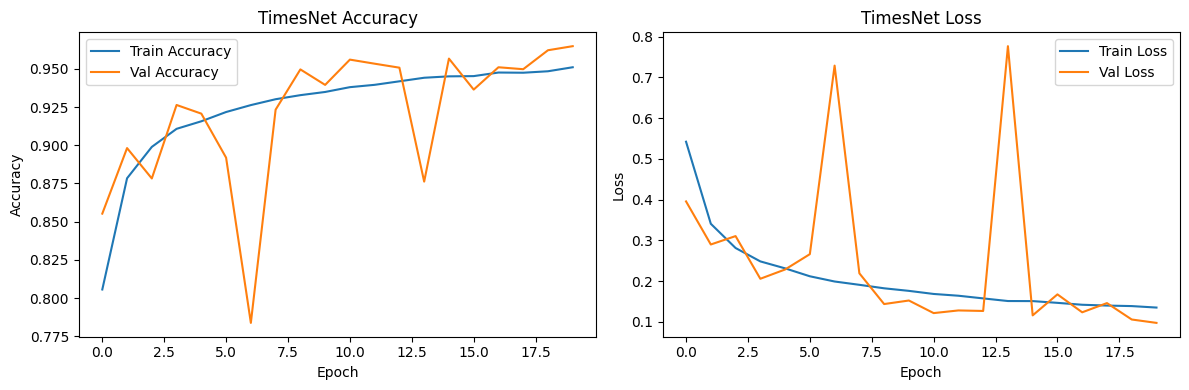

In [25]:
# Visualisasi Hasil Pelatihan TimesNet
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_gcn.history['accuracy'], label='Train Accuracy')
plt.plot(history_gcn.history['val_accuracy'], label='Val Accuracy')
plt.title('TimesNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_gcn.history['loss'], label='Train Loss')
plt.plot(history_gcn.history['val_loss'], label='Val Loss')
plt.title('TimesNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# Evaluasi Model TimesNet pada Test Set
start_time = time.time()
y_pred_ohe = gcn_model.predict(X_test)
end_time = time.time()

total_time_tn = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Hasil Evaluasi Dasar
loss_tn, accuracy_tn = gcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss_tn:.4f}")
print(f"Test Accuracy: {accuracy_tn:.4f}")
print(f"Total Prediction Time: {total_time_tn:.2f} detik")

print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step
Test Loss: 0.0968
Test Accuracy: 0.9637
Total Prediction Time: 9.58 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.922     0.933     0.927      3000
Supraventricular      0.954     0.923     0.938      3000
     Ventricular      0.983     0.975     0.979      3000
          Fusion      0.967     0.991     0.979      3000
         Unknown      0.993     0.996     0.995      3000

        accuracy                          0.964     15000
       macro avg      0.964     0.964     0.964     15000
    weighted avg      0.964     0.964     0.964     15000



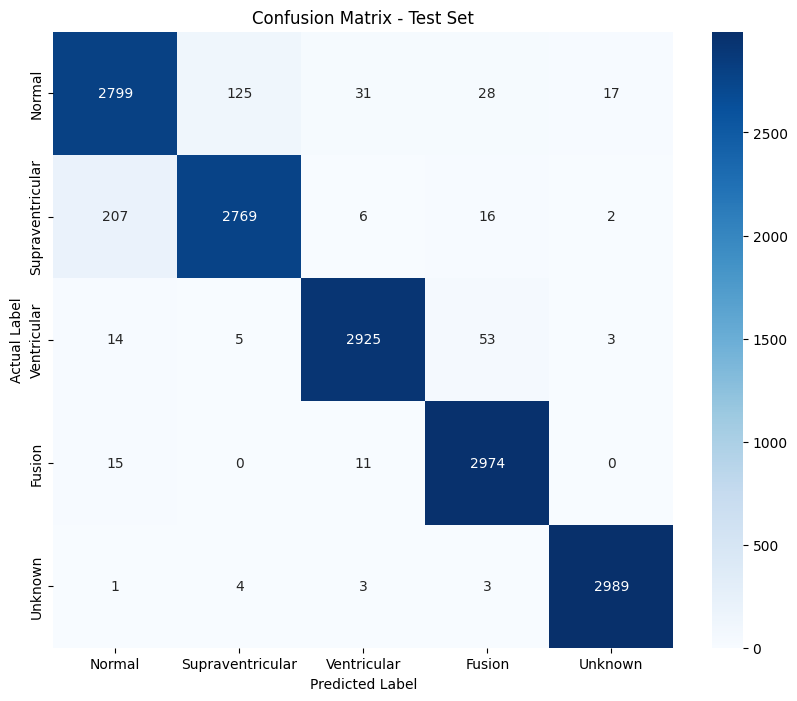

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

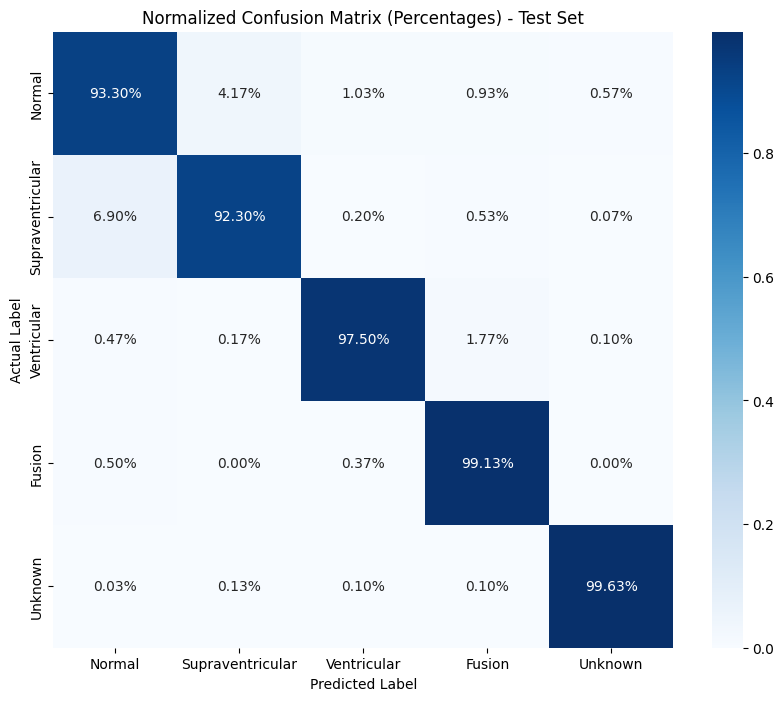

In [28]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (2)

In [13]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate2 = 0.005
epochs = 20
batch_size = 32

gcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate2),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history2 = gcn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7305 - loss: 0.7298
Epoch 1: val_accuracy improved from None to 0.88147, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 147s 63ms/step - accuracy: 0.8029 - loss: 0.5424 - val_accuracy: 0.8815 - val_loss: 0.3413
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8677 - loss: 0.3661
Epoch 2: val_accuracy did not improve from 0.88147
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.8733 - loss: 0.3452 - val_accuracy: 0.8754 - val_loss: 0.3445
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8882 - loss: 0.2980
Epoch 3: val_accuracy did not improve from 0.88147
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 139s 62ms/step - accuracy: 0.8910 - loss: 0.2920 - val_accuracy: 0.6208 - val_loss: 1.5283
Epoch 4/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9041 - loss: 0.2641
Epoch 4: val_accuracy did not improve 

# Evaluasi Metrik (2)

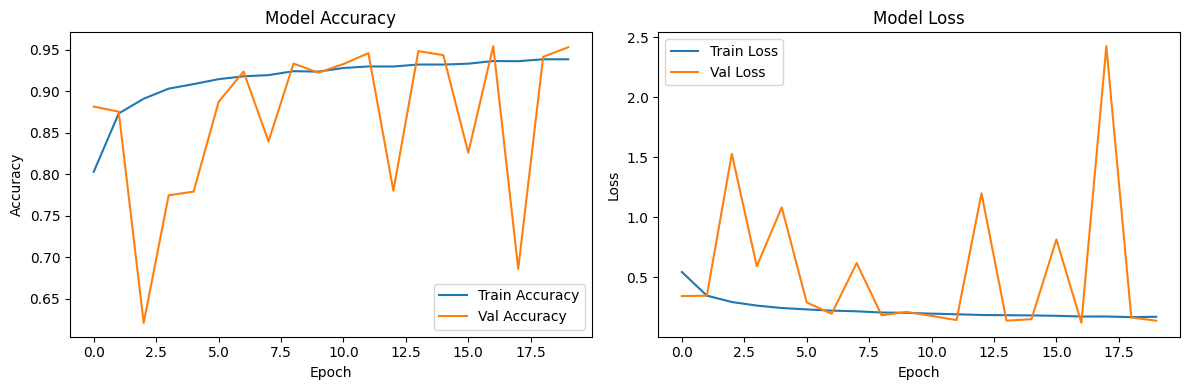

In [14]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = gcn_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time2 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss2, accuracy2 = gcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate2}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")
print(f"Total Prediction Time: {total_time2:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step
Learning Rate: 0.005
Epochs: 20
Batch size: 32
Test Loss: 0.1174
Test Accuracy: 0.9542
Total Prediction Time: 7.45 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.903     0.925     0.914      3000
Supraventricular      0.957     0.896     0.926      3000
     Ventricular      0.982     0.958     0.969      3000
          Fusion      0.939     0.995     0.966      3000
         Unknown      0.993     0.997     0.995      3000

        accuracy                          0.954     15000
       macro avg      0.955     0.954     0.954     15000
    weighted avg      0.955     0.954     0.954     15000



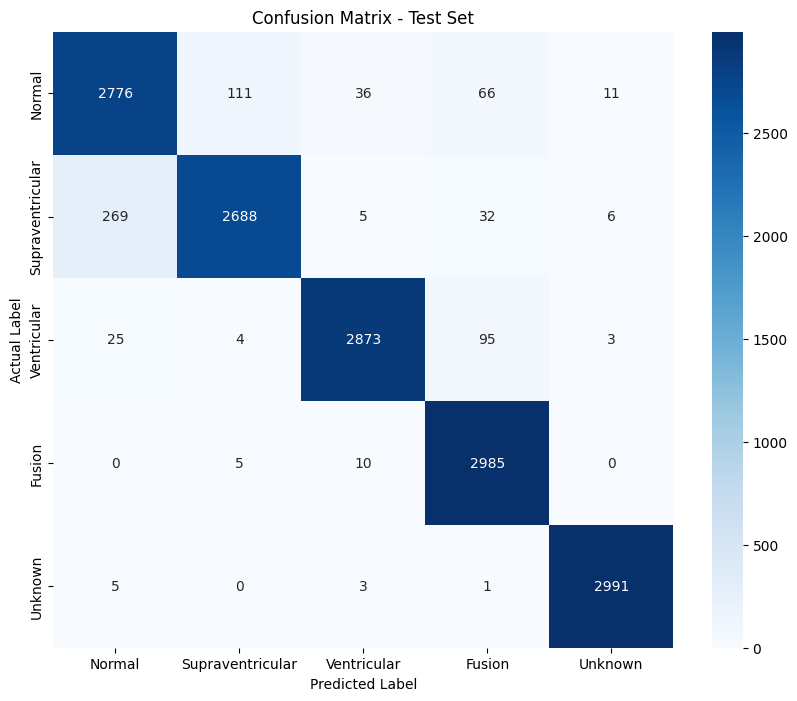

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

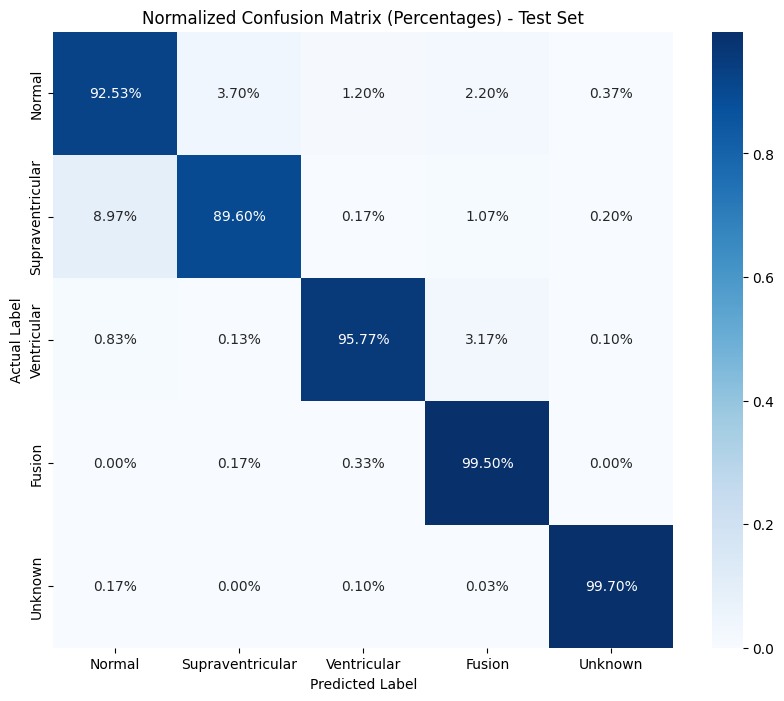

In [17]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (3)


In [18]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate3 = 0.001
epochs = 20
batch_size = 32

gcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = gcn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9463 - loss: 0.1389
Epoch 1: val_accuracy improved from None to 0.96453, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 154s 67ms/step - accuracy: 0.9487 - loss: 0.1363 - val_accuracy: 0.9645 - val_loss: 0.1002
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9512 - loss: 0.1323
Epoch 2: val_accuracy improved from 0.96453 to 0.96847, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.9517 - loss: 0.1305 - val_accuracy: 0.9685 - val_loss: 0.0917
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9533 - loss: 0.1239
Epoch 3: val_accuracy did not improve from 0.96847
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9532 - loss: 0.1246 - val_accuracy: 0.9663 - val_loss: 0.0903
Epoch 4/20
2187/2188 ━━━━━━━━━━━━━━━━

# Evaluasi Metrik (3)


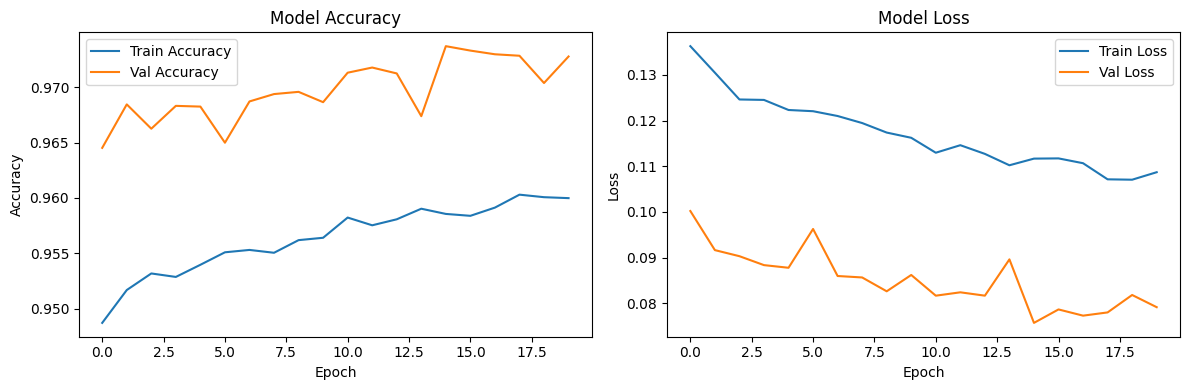

In [19]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = gcn_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time3 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss3, accuracy3 = gcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate3}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss3:.4f}")
print(f"Test Accuracy: {accuracy3:.4f}")
print(f"Total Prediction Time: {total_time3:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step
Learning Rate: 0.001
Epochs: 20
Batch size: 32
Test Loss: 0.0749
Test Accuracy: 0.9743
Total Prediction Time: 7.99 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.958     0.936     0.947      3000
Supraventricular      0.952     0.966     0.959      3000
     Ventricular      0.988     0.979     0.983      3000
          Fusion      0.977     0.994     0.986      3000
         Unknown      0.996     0.997     0.997      3000

        accuracy                          0.974     15000
       macro avg      0.974     0.974     0.974     15000
    weighted avg      0.974     0.974     0.974     15000



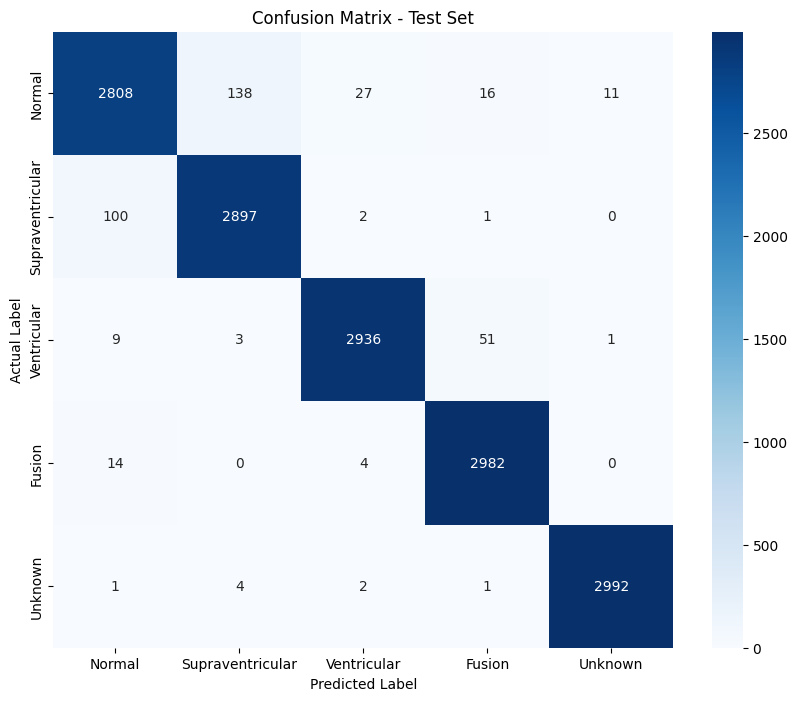

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

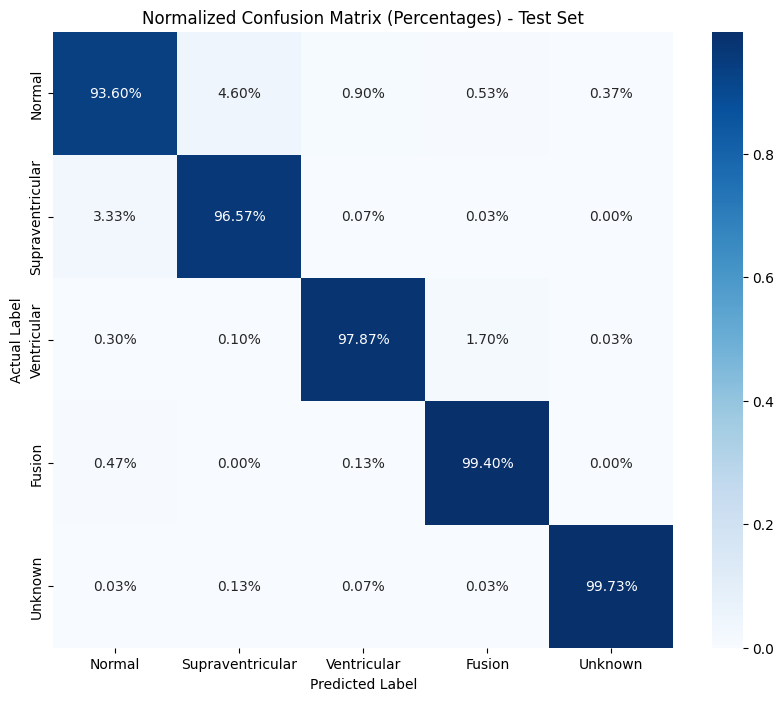

In [22]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (4)

In [23]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate4 = 0.0005
epochs = 20
batch_size = 32

gcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = gcn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9598 - loss: 0.1084
Epoch 1: val_accuracy improved from None to 0.97500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 156s 69ms/step - accuracy: 0.9605 - loss: 0.1065 - val_accuracy: 0.9750 - val_loss: 0.0716
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9613 - loss: 0.1038
Epoch 2: val_accuracy did not improve from 0.97500
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 197s 66ms/step - accuracy: 0.9613 - loss: 0.1044 - val_accuracy: 0.9746 - val_loss: 0.0733
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9594 - loss: 0.1049
Epoch 3: val_accuracy did not improve from 0.97500
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 202s 66ms/step - accuracy: 0.9608 - loss: 0.1037 - val_accuracy: 0.9741 - val_loss: 0.0733
Epoch 4/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9611 - loss: 0.1044
Epoch 4: val_accuracy did not improve 

# Evaluasi Metrik (4)

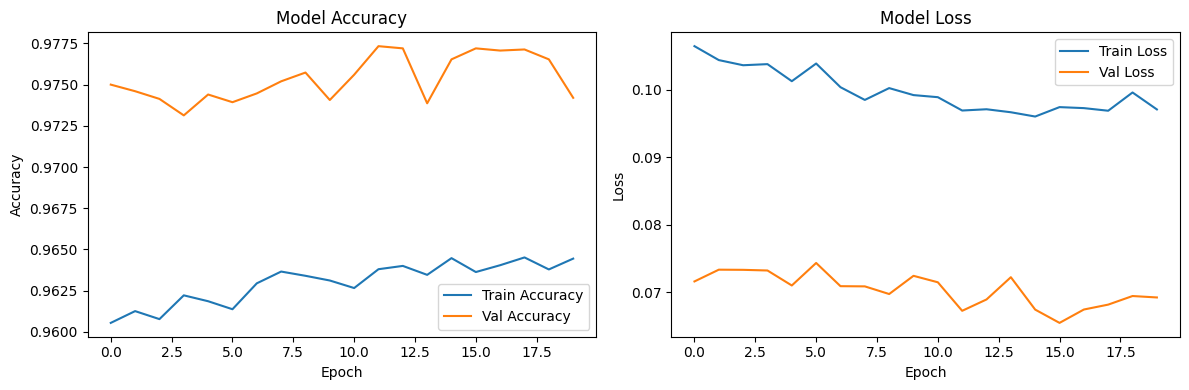

In [24]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = gcn_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time4 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss4, accuracy4 = gcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate4}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss4:.4f}")
print(f"Test Accuracy: {accuracy4:.4f}")
print(f"Total Prediction Time: {total_time4:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step
Learning Rate: 0.0005
Epochs: 20
Batch size: 32
Test Loss: 0.0684
Test Accuracy: 0.9790
Total Prediction Time: 12.17 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.966     0.946     0.956      3000
Supraventricular      0.961     0.973     0.967      3000
     Ventricular      0.991     0.981     0.986      3000
          Fusion      0.979     0.998     0.988      3000
         Unknown      0.998     0.997     0.997      3000

        accuracy                          0.979     15000
       macro avg      0.979     0.979     0.979     15000
    weighted avg      0.979     0.979     0.979     15000



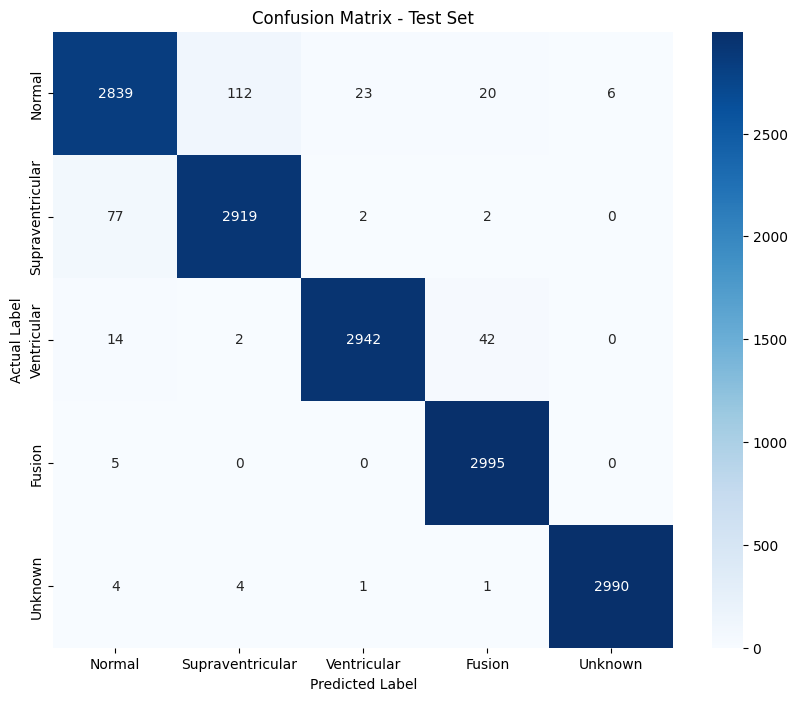

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

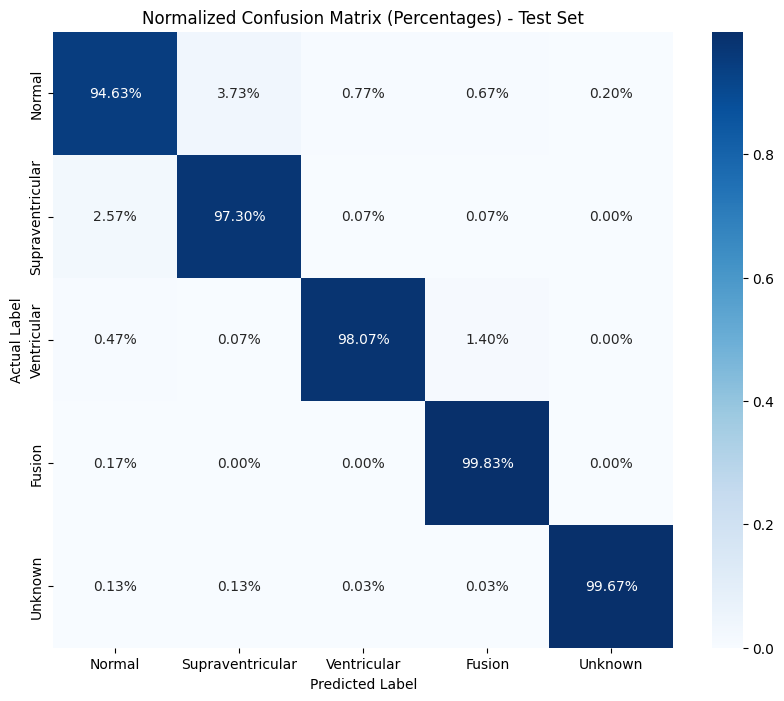

In [27]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Membuat data untuk tabel ringkasan
data = {
  'Model': ['Timesnet'],
  'Learning Rate': [learning_rate1, learning_rate2, learning_rate3, learning_rate4],
  'Epochs': [epochs, epochs, epochs, epochs],
  'Batch Size': [batch_size, batch_size, batch_size, batch_size],
  'Test Loss': [f"{loss1:.4f}", f"{loss2:.4f}", f"{loss3:.4f}", f"{loss4:.4f}"],
  'Test Accuracy': [f"{accuracy1*100:.2f}%", f"{accuracy2*100:.2f}%", f"{accuracy3*100:.2f}%", f"{accuracy4*100:.2f}%"],
  'Eval Runtime (Detik)': [total_time1, total_time2, total_time3, total_time4]
}

df_summary = pd.DataFrame(data)
print("Summary Statistik Performa Model ViT:")
display(df_summary)

# Penyimpanan dan Deployment

In [30]:
# 1. Simpan Model TimesNet
gcn_model.save('mitbih_timesnet.keras')
print("Model berhasil disimpan sebagai 'mitbih_gcn_model.keras'")

# 2. Simpan OneHotEncoder
with open('encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)
print("Encoder berhasil disimpan sebagai 'encoder.pkl'")

Model berhasil disimpan sebagai 'mitbih_gcn_model.keras'
Encoder berhasil disimpan sebagai 'encoder.pkl'
